In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import matplotlib.pyplot as plt
import random

In [2]:
X_train = np.loadtxt('/kaggle/input/catdogdataset/input.csv', delimiter=',')
Y_train = np.loadtxt('/kaggle/input/catdogdataset/labels.csv', delimiter=',')
X_test = np.loadtxt('/kaggle/input/catdogdataset/input_test.csv', delimiter=',')
Y_test = np.loadtxt('/kaggle/input/catdogdataset/labels_test.csv', delimiter=',')

Need to reshape the data

In [3]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
print("X_train shape: ", X_train.shape)
print("Y_train shape: ", Y_train.shape)
print("X_test shape: ", X_test.shape)
print("Y_test shape: ", Y_test.shape)

X_train shape:  (2000, 100, 100, 3)
Y_train shape:  (2000, 1)
X_test shape:  (400, 100, 100, 3)
Y_test shape:  (400, 1)


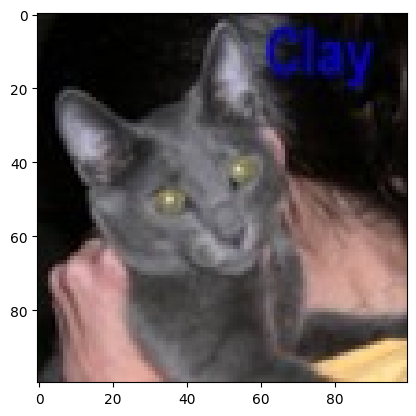

In [5]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx,:])
plt.show()

## **Model**

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (100, 100, 3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [8]:
model.fit(X_train, Y_train, epochs=5, batch_size=64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 367ms/step - accuracy: 0.4957 - loss: 0.8140
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 385ms/step - accuracy: 0.5683 - loss: 0.6798
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 0.6464 - loss: 0.6166
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 364ms/step - accuracy: 0.6807 - loss: 0.5831
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.7480 - loss: 0.5283


In [9]:
model.evaluate(X_test, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7877 - loss: 0.4514


[0.7072321176528931, 0.6100000143051147]

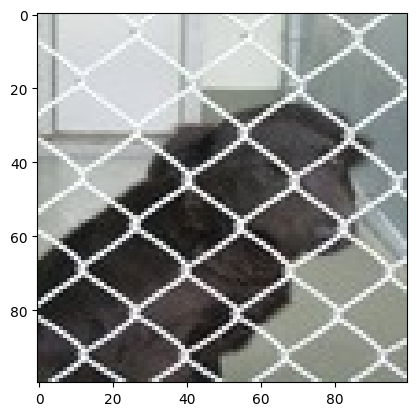

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
The model says it is a : dog


In [10]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'dog'
else:
    pred = 'cat'
    
print("The model says it is a :", pred)